In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
from pandas.core.resample import PeriodIndexResampler
df = pd.read_csv('data.csv')
print(df)


          Price              Status  Area Rate per sqft  \
0      10700000  Under Construction  1138         9,450   
1      14400000  Under Construction  1528         9,450   
2      10700000  Under Construction  1138         9,450   
3      40000000       Ready to move  4500         8,888   
4      24000000  Under Construction  1800        13,333   
...         ...                 ...   ...           ...   
19510  24100000       Ready to move  1381        17,500   
19511  36200000       Ready to move  2072        17,500   
19512  39100000  Under Construction  2445        16,002   
19513  37700000  Under Construction  2360        16,001   
19514  36500000  Under Construction  2282        16,005   

                                           Property Type    Locality  \
0           2 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
1           3 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
2           2 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
3  

In [44]:
print(df.columns.tolist())

['Price', 'Status', 'Area', 'Rate per sqft', 'Property Type', 'Locality', 'Builder Name', 'RERA Approval', 'BHK_Count', 'Society', 'Company Name', 'Flat Type']


In [45]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Price          19515 non-null  str  
 1   Status         19515 non-null  str  
 2   Area           19515 non-null  int64
 3   Rate per sqft  19515 non-null  str  
 4   Property Type  19515 non-null  str  
 5   Locality       19515 non-null  str  
 6   Builder Name   19515 non-null  str  
 7   RERA Approval  19515 non-null  str  
 8   BHK_Count      19515 non-null  int64
 9   Society        19515 non-null  str  
 10  Company Name   19515 non-null  str  
 11  Flat Type      19515 non-null  str  
dtypes: int64(2), str(10)
memory usage: 1.8 MB
None


In [46]:
#data cleaning
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['price', 'status', 'area', 'rate_per_sqft', 'property_type', 'locality', 'builder_name', 'rera_approval', 'bhk_count', 'society', 'company_name', 'flat_type']


In [47]:
 # numerical columns cleaning
 
 
df["price"] = df["price"].astype(str).str.replace(",", "").astype(int)
df["area"] = df["area"].astype(str).str.replace(",", "").astype(int)
df["rate_per_sqft"] = df["rate_per_sqft"].astype(str).str.replace(",", "").astype(int)

print(df['price'])
print(df['area'])
print(df['rate_per_sqft'])


0        10700000
1        14400000
2        10700000
3        40000000
4        24000000
           ...   
19510    24100000
19511    36200000
19512    39100000
19513    37700000
19514    36500000
Name: price, Length: 19515, dtype: int64
0        1138
1        1528
2        1138
3        4500
4        1800
         ... 
19510    1381
19511    2072
19512    2445
19513    2360
19514    2282
Name: area, Length: 19515, dtype: int64
0         9450
1         9450
2         9450
3         8888
4        13333
         ...  
19510    17500
19511    17500
19512    16002
19513    16001
19514    16005
Name: rate_per_sqft, Length: 19515, dtype: int64


In [48]:
# categorical cloumns cleaning

df["status"] = df["status"].str.strip().str.lower()
df["rera_approval"] = df["rera_approval"].str.strip().str.lower().map({'approved by rera':True,'not approved by rera':False})
df["flat_type"] = df["flat_type"].str.strip().str.lower()

print(df['rera_approval'])

0         True
1         True
2         True
3        False
4         True
         ...  
19510    False
19511    False
19512     True
19513     True
19514     True
Name: rera_approval, Length: 19515, dtype: bool


In [49]:
print(df['status'])
print(df['flat_type'])

0        under construction
1        under construction
2        under construction
3             ready to move
4        under construction
                ...        
19510         ready to move
19511         ready to move
19512    under construction
19513    under construction
19514    under construction
Name: status, Length: 19515, dtype: str
0        apartment
1        apartment
2        apartment
3             plot
4            floor
           ...    
19510    apartment
19511    apartment
19512    apartment
19513    apartment
19514    apartment
Name: flat_type, Length: 19515, dtype: str


In [50]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   price          19515 non-null  int64
 1   status         19515 non-null  str  
 2   area           19515 non-null  int64
 3   rate_per_sqft  19515 non-null  int64
 4   property_type  19515 non-null  str  
 5   locality       19515 non-null  str  
 6   builder_name   19515 non-null  str  
 7   rera_approval  19515 non-null  bool 
 8   bhk_count      19515 non-null  int64
 9   society        19515 non-null  str  
 10  company_name   19515 non-null  str  
 11  flat_type      19515 non-null  str  
dtypes: bool(1), int64(4), str(7)
memory usage: 1.7 MB
None


In [51]:
# Q1  which is the costliest flat in the dataset ?

costliest_flat=df.loc[df["price"].idxmax()]
'''"
let write this output as sentence:
price                                  1226300000
status                              ready to move
area                                        16500
rate_per_sqft                               74323
property_type    6 BHK Apartment in DLF Camellias
locality                                Sector 42
builder_name                    Provident Capital
rera_approval                               False
bhk_count                                       6
society                             DLF Camellias
company_name                                  DLF
flat_type                               apartment
Name: 2839, dtype: object

'''

print(f"the costliest flat is a {costliest_flat['bhk_count']}bhk flat located in {costliest_flat['locality']} priced at{costliest_flat['price']/10000000} cr in {costliest_flat['society']} society.")

the costliest flat is a 6bhk flat located in Sector 42 priced at122.63 cr in  DLF Camellias society.


In [54]:
# Q2 which  locality has highest  averange price?
highest_avg_price_locality=df.groupby('locality')['price'].mean().idxmax()
print(f"the locality with the highest average price is {highest_avg_price_locality}.")

the locality with the highest average price is Baliawas.


In [53]:
# Q3 which locality  has the highest rate per square foot?

highest_rate_locality=df.groupby('locality')['rate_per_sqft'].mean().idxmax()
print(f"the locality with the highest rate per square foot is {highest_rate_locality}.")

the locality with the highest rate per square foot is Sector 113.


In [55]:
# Q4 Do ready-to-move properties cost more than under-construction properties?


ready_to_move_average_price=df[df['status']=='ready to move']['price'].mean()
under_construction_avg_price=df[df['status']=='under construction']['price'].mean()

if ready_to_move_average_price>under_construction_avg_price:
    print("ready-to-move properties cost more on avreage the under-construction properties.")
else:
    print("under-construction properties cost more on avg than ready-to-move properties.")

under-construction properties cost more on avg than ready-to-move properties.


In [ ]:
# Q5 Do RERA-approved properties command a price premium?
rera_approved_avg_price = df[df['rera_approval'] == True]['price'].mean()
rera_not_approved_avg_price = df[df['rera_approval'] == False]['price'].mean()

if rera_approved_avg_price > rera_not_approved_avg_price:
    print("RERA-approved properties command a price premium.")
else:
    print("RERA-approved properties do not command a price premium.")

RERA-approved properties command a price premium.


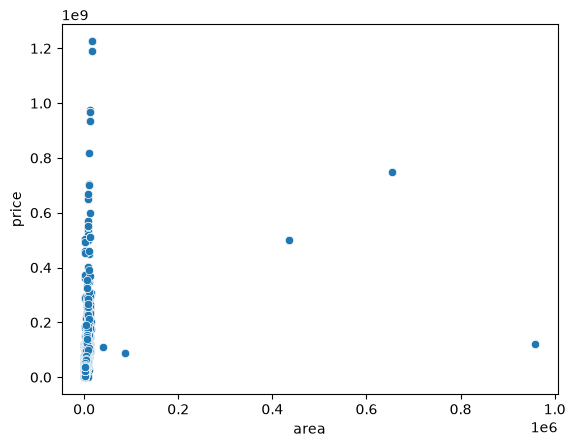

In [60]:
# Q6 How does area (sqft) impact property price?

sns.scatterplot(x="area", y="price", data=df)
plt.show()

In [64]:
# Q7 Which BHK configuration is the most expensive on average?

most_expensive_bhk = df.groupby('bhk_count')['rate_per_sqft'].mean().idxmax()
print(f"The most expensive BHK configuration on average is {most_expensive_bhk} BHK.")

The most expensive BHK configuration on average is 114 BHK.


In [63]:
# Q8 Which property type is the costliest?
most_expensive_property_type = df.groupby('flat_type')['rate_per_sqft'].mean().idxmax()
print(f"The most expensive property type is {most_expensive_property_type}.")

The most expensive property type is villa.


In [65]:
# Question 9: Do certain builders price higher?
print(df.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False).head(5))
# print name of top 5
print("The top 5 builders that price higher are:", end=" ")
top_5_builders = df.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False).head(5)
for builder in top_5_builders.index:
    print(builder, end=", ")

company_name
Camelliaass    44724.333333
Cameliaas      40000.000000
Tulip          29093.640625
Magnoliaass    26666.000000
Mah            25873.688525
Name: rate_per_sqft, dtype: float64
The top 5 builders that price higher are: Camelliaass, Cameliaas, Tulip, Magnoliaass, Mah, 

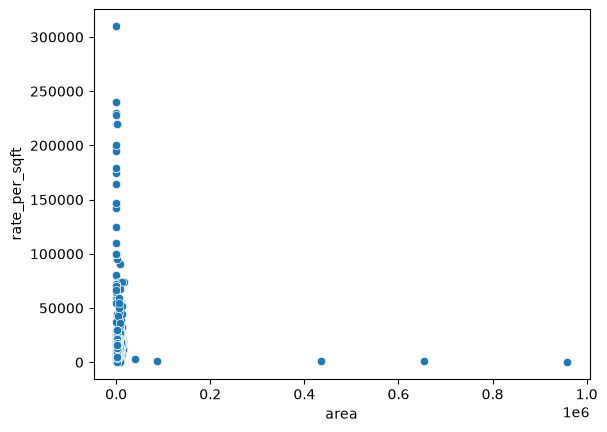

In [ ]:
# 10 Are larger homes always more expensive per square foot?

sns.scatterplot(x="area", y="rate_per_sqft", data=df)
plt.show()

# ans=no